# Лабораторная работа 3. Фильтрация изображений


### Задание: попробуйте выполнить низкочастотную фильтрацию в частотной области зашумленного изображения, как это сделано в разделе 3.1. Сделайте выводы.

In [11]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


# SSIM оценивает, насколько структура изображения сохранилась после фильтрации.
def ssim(first, second):
    first = first.astype(np.float32)
    second = second.astype(np.float32)
    mean_first = cv.GaussianBlur(first, (11, 11), 1.5)
    mean_second = cv.GaussianBlur(second, (11, 11), 1.5)
    var_first = cv.GaussianBlur(first * first, (11, 11), 1.5) - mean_first ** 2
    var_second = cv.GaussianBlur(second * second, (11, 11), 1.5) - mean_second ** 2
    covariance = cv.GaussianBlur(first * second, (11, 11), 1.5) - mean_first * mean_second
    numerator = (2 * mean_first * mean_second + 6.5025) * (2 * covariance + 58.5225)
    denominator = (mean_first ** 2 + mean_second ** 2 + 6.5025) * (var_first + var_second + 58.5225)
    return float(np.mean(numerator / denominator))


# Загружаем выданный негатив и получаем изображение с обычными цветами.
image = cv.imread('3_d284c976dd4a54ae.jpg')
if image is None:
    raise FileNotFoundError('3_d284c976dd4a54ae.jpg')

original = cv.bitwise_not(image)
# Добавляем гауссов шум, чтобы сравнить способы его подавления.
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.15, original.shape)
noisy = np.uint8(np.clip(original / 255.0 + noise, 0, 1) * 255)


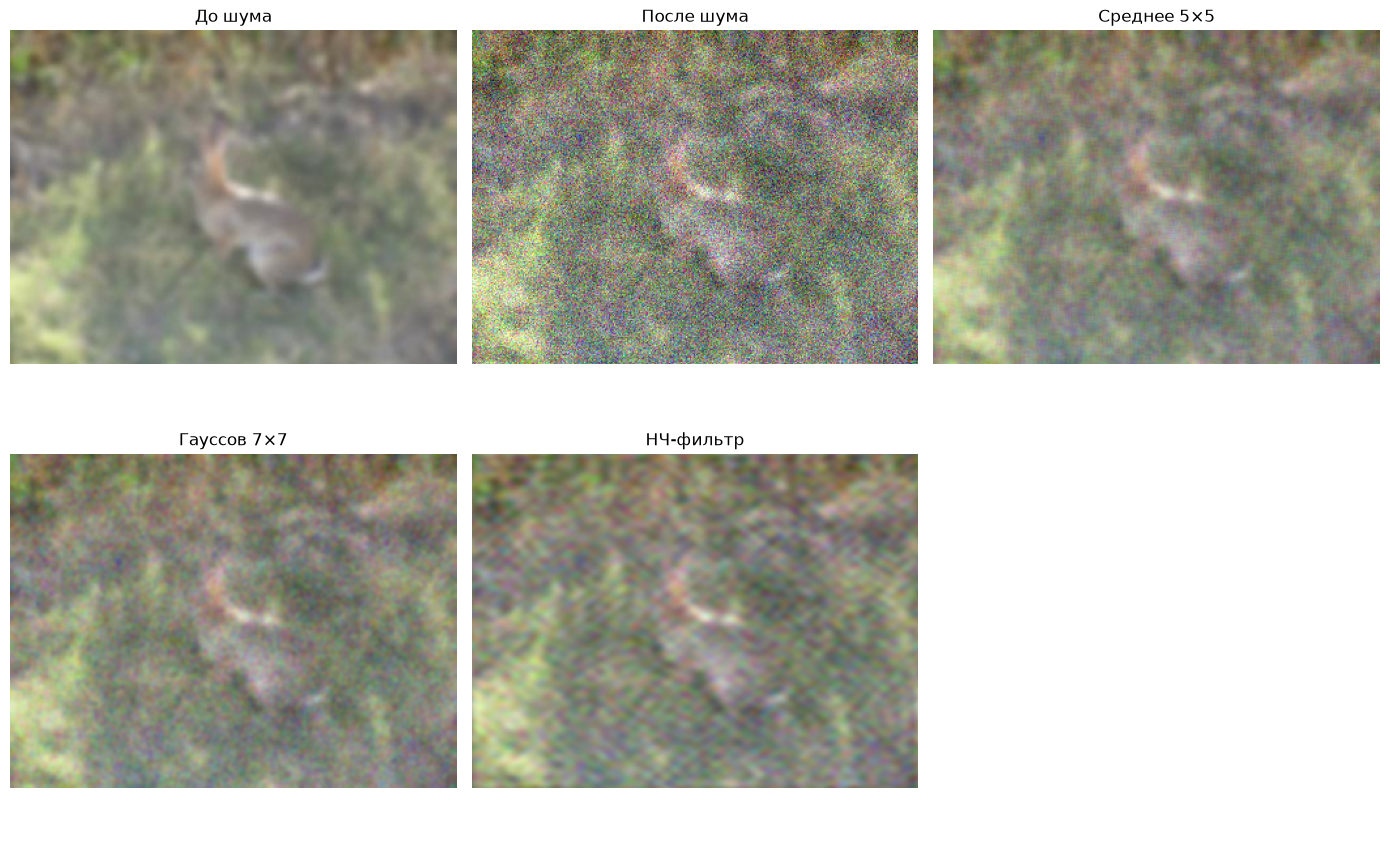

После шума: PSNR=16.50, SSIM=0.067
Среднее 5×5: PSNR=30.17, SSIM=0.715
Гауссов 7×7: PSNR=30.18, SSIM=0.730
НЧ-фильтр: PSNR=29.88, SSIM=0.764


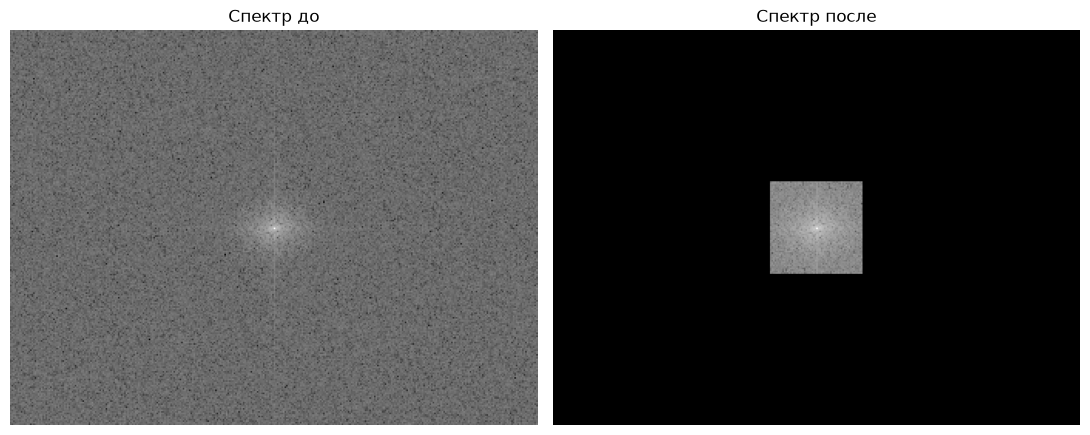

True

In [12]:
# Пространственные фильтры усредняют соседние пиксели.
kernel = np.ones((5, 5), np.float32) / 25
mean_filtered = cv.filter2D(noisy, -1, kernel)
gaussian_filtered = cv.GaussianBlur(noisy, (7, 7), 0)

# Маска пропускает низкие частоты в центре спектра и убирает высокие.
radius = 30
height, width = noisy.shape[:2]
mask = np.zeros((height, width, 2), np.float32)
mask[height // 2 - radius:height // 2 + radius,
     width // 2 - radius:width // 2 + radius] = 1

# Применяем преобразование Фурье отдельно к каждому цветовому каналу.
filtered_channels = []
for channel in cv.split(noisy):
    spectrum = cv.dft(channel.astype(np.float32), flags=cv.DFT_COMPLEX_OUTPUT)
    spectrum = np.fft.fftshift(spectrum, axes=(0, 1))
    filtered_spectrum = spectrum * mask
    restored = cv.idft(np.fft.ifftshift(filtered_spectrum, axes=(0, 1)),
                       flags=cv.DFT_SCALE | cv.DFT_REAL_OUTPUT)
    filtered_channels.append(np.uint8(np.clip(restored, 0, 255)))
frequency_filtered = cv.merge(filtered_channels)

# Показываем исходное, зашумленное и отфильтрованные изображения.
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
images = [
    ('До шума', original), ('После шума', noisy),
    ('Среднее 5×5', mean_filtered), ('Гауссов 7×7', gaussian_filtered),
    ('НЧ-фильтр', frequency_filtered),
]
for ax, (title, picture) in zip(axes.flat, images):
    ax.imshow(cv.cvtColor(picture, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

# PSNR и SSIM сравнивают каждый вариант с изображением до добавления шума.
for title, picture in images[1:]:
    print(f'{title}: PSNR={cv.PSNR(original, picture):.2f}, SSIM={ssim(original, picture):.3f}')

# На спектрах видно, какие частоты остались после наложения маски.
gray = cv.cvtColor(noisy, cv.COLOR_BGR2GRAY).astype(np.float32)
spectrum = np.fft.fftshift(cv.dft(gray, flags=cv.DFT_COMPLEX_OUTPUT), axes=(0, 1))
filtered_spectrum = spectrum * mask
before = np.log1p(cv.magnitude(spectrum[:, :, 0], spectrum[:, :, 1]))
after = np.log1p(cv.magnitude(filtered_spectrum[:, :, 0], filtered_spectrum[:, :, 1]))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (title, picture) in zip(axes, [('Спектр до', before), ('Спектр после', after)]):
    ax.imshow(picture, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

cv.imwrite('lab3_frequency_result.png', frequency_filtered)


![НЧ-фильтрация](lab3_frequency_result.png)


#**Задание. Для выданного преподавателем изображения создайте программу улучшающую это изображение.**

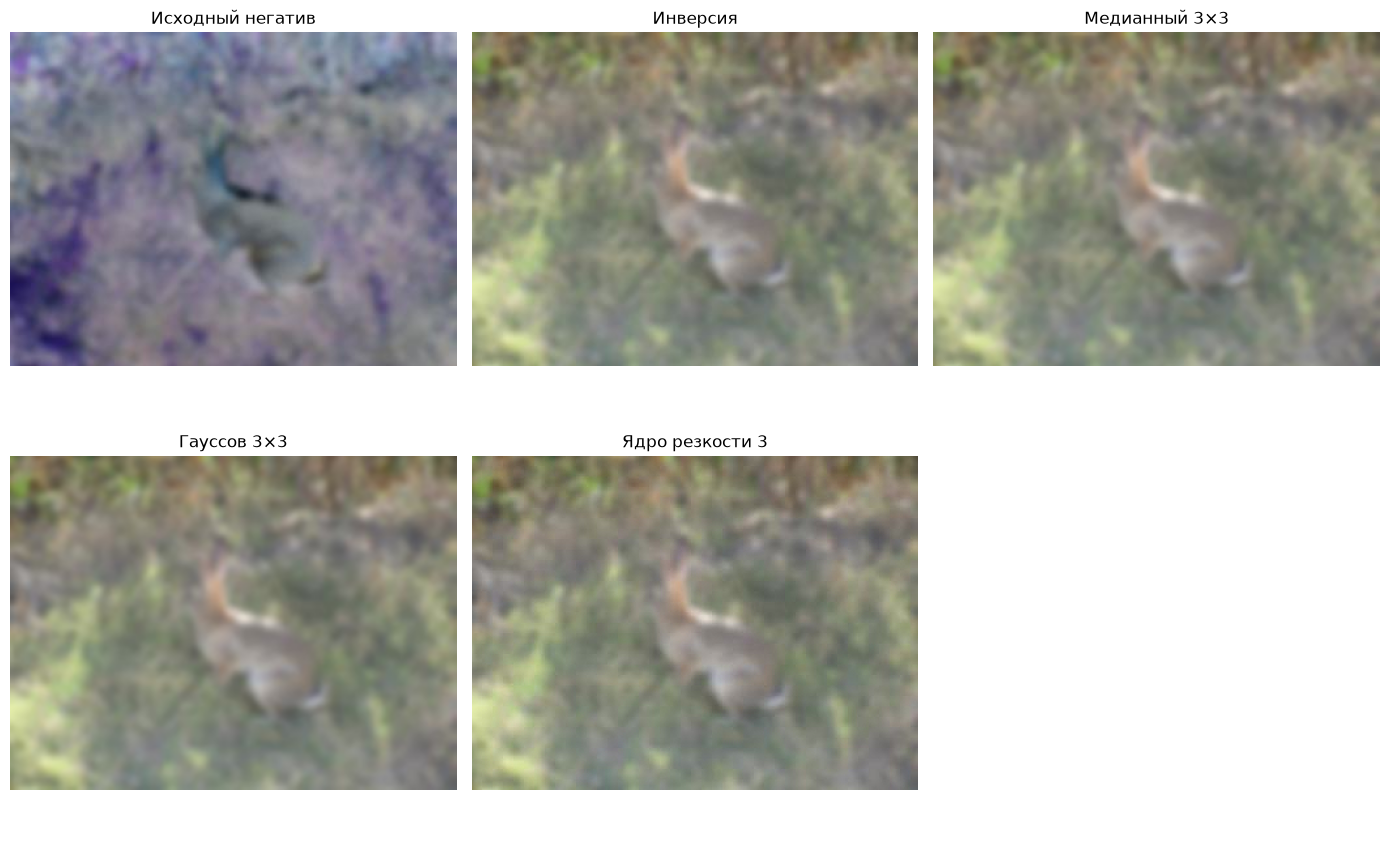

True

In [13]:
# Инвертируем негатив и сравниваем мягкое сглаживание с повышением резкости.
positive = cv.bitwise_not(image)
median = cv.medianBlur(positive, 3)
gaussian = cv.GaussianBlur(positive, (3, 3), 0)
kernel = np.array([[0, -0.25, 0], [-0.25, 2, -0.25], [0, -0.25, 0]], np.float32)
sharpened = cv.filter2D(positive, -1, kernel)
# Сохраняем инверсию: дополнительные фильтры здесь заметно размывают детали.
result = positive

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (title, picture) in zip(axes.flat, [
    ('Исходный негатив', image), ('Инверсия', positive),
    ('Медианный 3×3', median), ('Гауссов 3×3', gaussian),
    ('Ядро резкости 3', sharpened),
]):
    ax.imshow(cv.cvtColor(picture, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

cv.imwrite('lab3_result.jpg', result, [cv.IMWRITE_JPEG_QUALITY, 100])


![Результат](lab3_result.jpg)
